In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set some visual preferences for our plots
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

In [3]:
# Load the dataset
df = pd.read_csv('House_Price_Prediction.csv')

In [4]:
# --- Initial Inspection ---

In [5]:
# Display the first 5 rows
print("First 5 Rows:")
print(df.head())

First 5 Rows:
                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated         

In [6]:
# Display data types and non-null counts
print("\nDataset Info:")
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object

In [7]:
# Get statistical summary for numerical columns
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
              price     bedrooms    bathrooms   sqft_living      sqft_lot  \
count  4.600000e+03  4600.000000  4600.000000   4600.000000  4.600000e+03   
mean   5.519630e+05     3.400870     2.160815   2139.346957  1.485252e+04   
std    5.638347e+05     0.908848     0.783781    963.206916  3.588444e+04   
min    0.000000e+00     0.000000     0.000000    370.000000  6.380000e+02   
25%    3.228750e+05     3.000000     1.750000   1460.000000  5.000750e+03   
50%    4.609435e+05     3.000000     2.250000   1980.000000  7.683000e+03   
75%    6.549625e+05     4.000000     2.500000   2620.000000  1.100125e+04   
max    2.659000e+07     9.000000     8.000000  13540.000000  1.074218e+06   

            floors   waterfront         view    condition   sqft_above  \
count  4600.000000  4600.000000  4600.000000  4600.000000  4600.000000   
mean      1.512065     0.007174     0.240652     3.451739  1827.265435   
std       0.538288     0.084404     0.778405     0.677230   86

In [8]:
# Create a new dataframe containing only the rows with a price of 0
zero_price_homes = df[df['price'] == 0]

# Display all of these rows
print(f"Found {len(zero_price_homes)} homes with a price of 0. Here they are:")
zero_price_homes

Found 49 homes with a price of 0. Here they are:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
4354,2014-05-05 00:00:00,0.0,3.0,1.75,1490,10125,1.0,0,0,4,1490,0,1962,0,3911 S 328th St,Federal Way,WA 98001,USA
4356,2014-05-05 00:00:00,0.0,4.0,2.75,2600,5390,1.0,0,0,4,1300,1300,1960,2001,2120 31st Ave W,Seattle,WA 98199,USA
4357,2014-05-05 00:00:00,0.0,6.0,2.75,3200,9200,1.0,0,2,4,1600,1600,1953,1983,12271 Marine View Dr SW,Burien,WA 98146,USA
4358,2014-05-06 00:00:00,0.0,5.0,3.50,3480,36615,2.0,0,0,4,2490,990,1983,0,21809 SE 38th Pl,Issaquah,WA 98075,USA
4361,2014-05-07 00:00:00,0.0,5.0,1.50,1500,7112,1.0,0,0,5,760,740,1920,0,14901-14999 12th Ave SW,Burien,WA 98166,USA
4362,2014-05-07 00:00:00,0.0,4.0,4.00,3680,18804,2.0,0,0,3,3680,0,1990,2009,1223-1237 244th Ave NE,Sammamish,WA 98074,USA
4374,2014-05-09 00:00:00,0.0,2.0,2.50,2200,188200,1.0,0,3,3,2200,0,2007,0,39612 254th Ave SE,Enumclaw,WA 98022,USA
4376,2014-05-09 00:00:00,0.0,4.0,2.25,2170,10500,1.0,0,2,4,1270,900,1960,2001,216 SW 183rd St,Normandy Park,WA 98166,USA
4382,2014-05-12 00:00:00,0.0,5.0,4.50,4630,6324,2.0,0,0,3,3210,1420,2006,0,6925 Oakmont Ave SE,Snoqualmie,WA 98065,USA
4383,2014-05-13 00:00:00,0.0,5.0,4.00,4430,9000,2.0,0,0,3,4430,0,2013,1923,9235 NE 5th St,Bellevue,WA 98004,USA


In [9]:
#shape of our dataframe before cleaning
print(f"Original dataframe shape: {df.shape}")

Original dataframe shape: (4600, 18)


In [10]:
# Filter the dataframe to keep only the rows where price is not equal to 0
df = df[df['price'] != 0]

In [11]:
#shape of the dataframe after cleaning to confirm rows were removed
print(f"Shape after removing zero-priced houses: {df.shape}")

Shape after removing zero-priced houses: (4551, 18)


In [12]:
#Convert the 'date' column to a datetime object
# Use pandas' to_datetime function to convert the column
df['date'] = pd.to_datetime(df['date'])

In [13]:
print("\nVerifying data type of 'date' column after conversion:")
df.info()


Verifying data type of 'date' column after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4551 non-null   datetime64[ns]
 1   price          4551 non-null   float64       
 2   bedrooms       4551 non-null   float64       
 3   bathrooms      4551 non-null   float64       
 4   sqft_living    4551 non-null   int64         
 5   sqft_lot       4551 non-null   int64         
 6   floors         4551 non-null   float64       
 7   waterfront     4551 non-null   int64         
 8   view           4551 non-null   int64         
 9   condition      4551 non-null   int64         
 10  sqft_above     4551 non-null   int64         
 11  sqft_basement  4551 non-null   int64         
 12  yr_built       4551 non-null   int64         
 13  yr_renovated   4551 non-null   int64         
 14  street         4551 n

In [14]:
#Univariate Analysis - Analyzing the Target Variable (price)

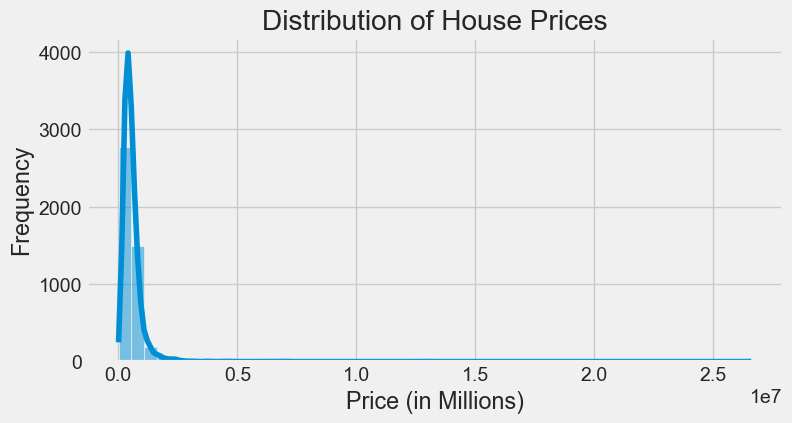

In [15]:
# Plot the distribution of the house prices
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Distribution of House Prices')
plt.xlabel('Price (in Millions)')
plt.ylabel('Frequency')
plt.show()

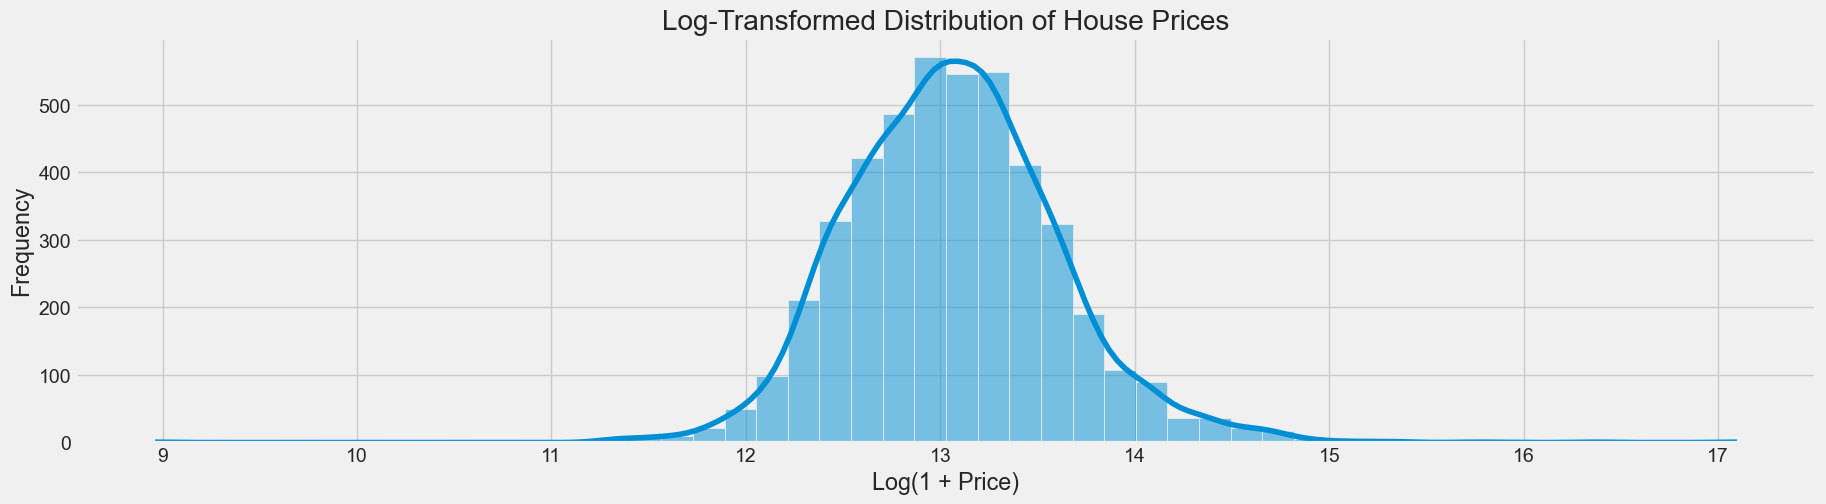

In [16]:
# Plot the log-transformed distribution of house prices - normal distribution 
plt.figure(figsize=(20, 5))
sns.histplot(np.log1p(df['price']), kde=True, bins=50)
plt.title('Log-Transformed Distribution of House Prices')
plt.xlabel('Log(1 + Price)')
plt.ylabel('Frequency')
plt.show()

In [17]:
# Univariate Analysis - Visualizing Numerical Features

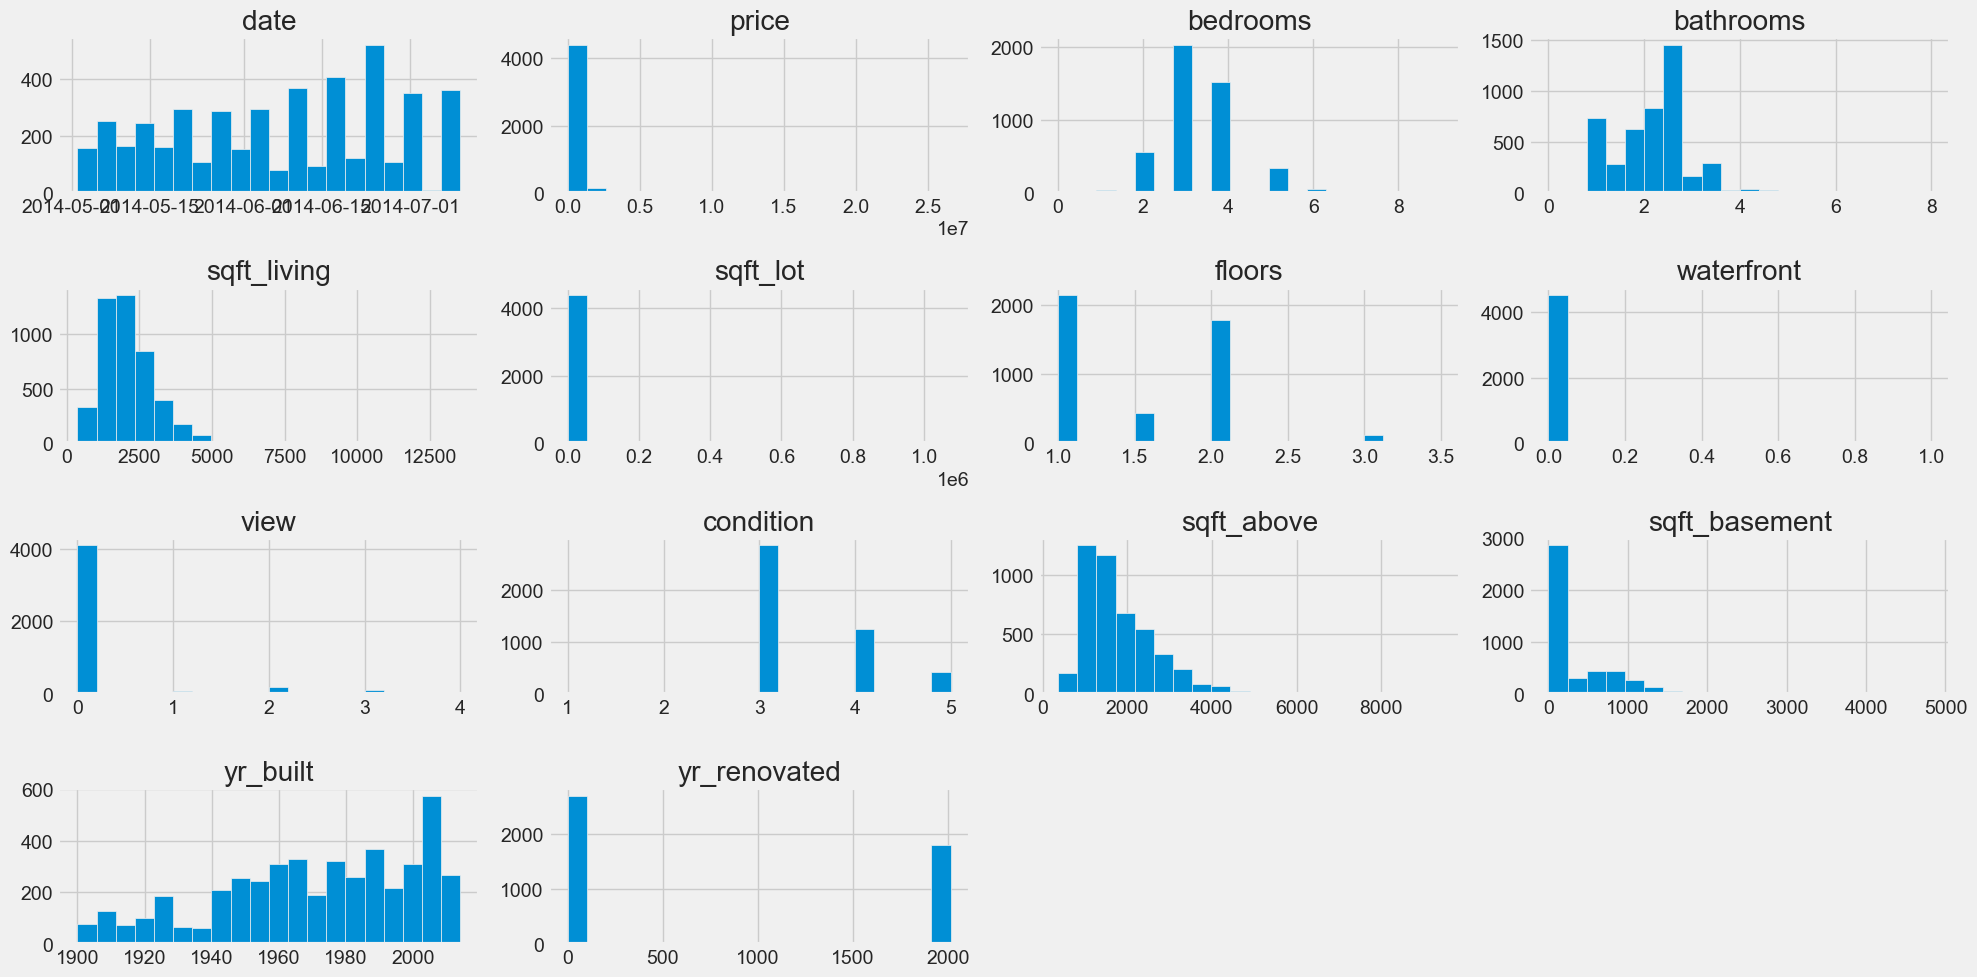

In [18]:
# Create histograms for all numerical features to see their distributions
df.hist(bins=20, figsize=(20, 10))
plt.tight_layout() # This function adjusts plot params for a tight layout.
plt.show()

In [19]:
#Univariate Analysis - Visualizing Categorical Features

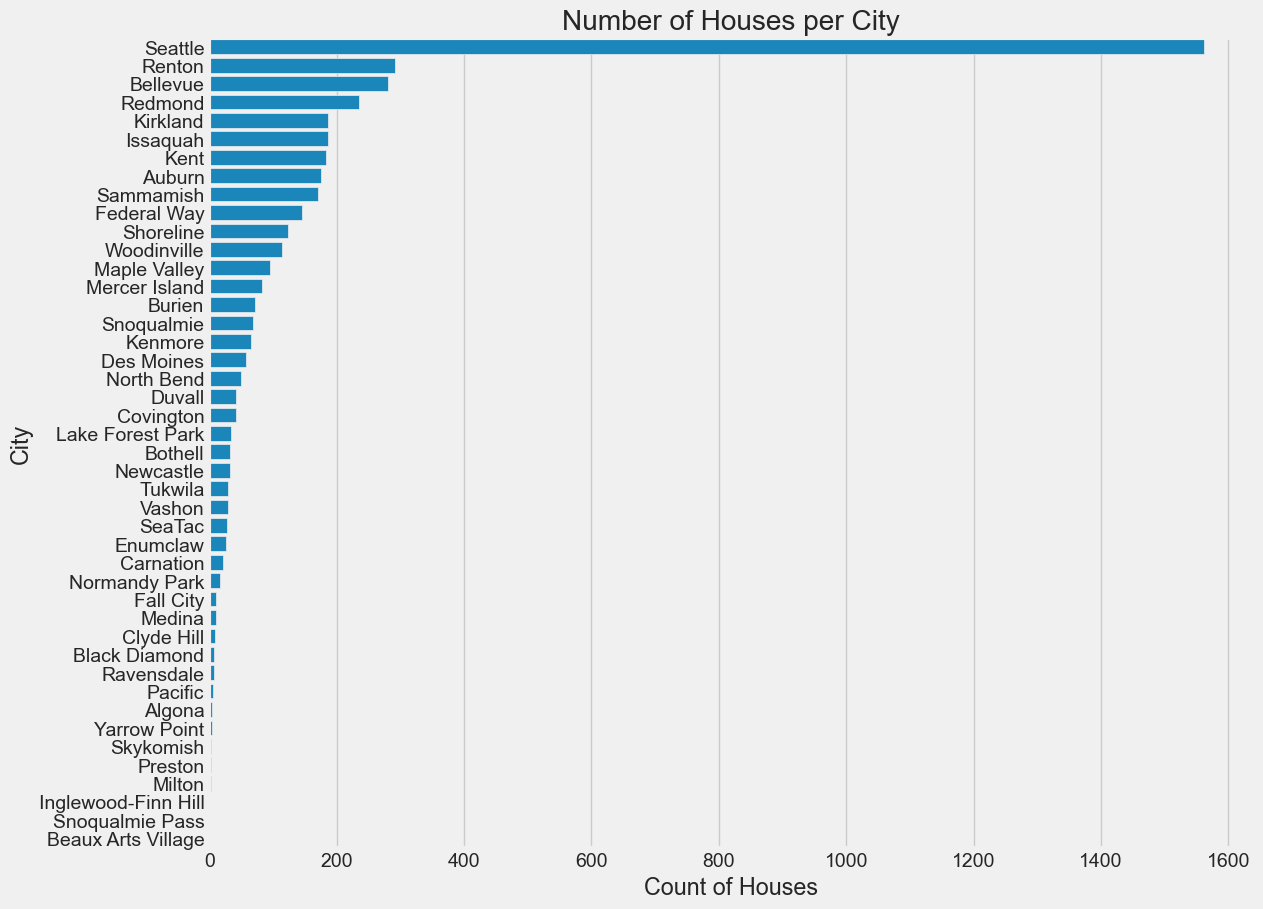

In [20]:
# Analyze the 'city' column
plt.figure(figsize=(12, 10))
sns.countplot(y='city', data=df, order=df['city'].value_counts().index)
plt.title('Number of Houses per City')
plt.xlabel('Count of Houses')
plt.ylabel('City')
plt.show()

In [21]:
#Bivariate Analysis - Numerical Features vs. Price

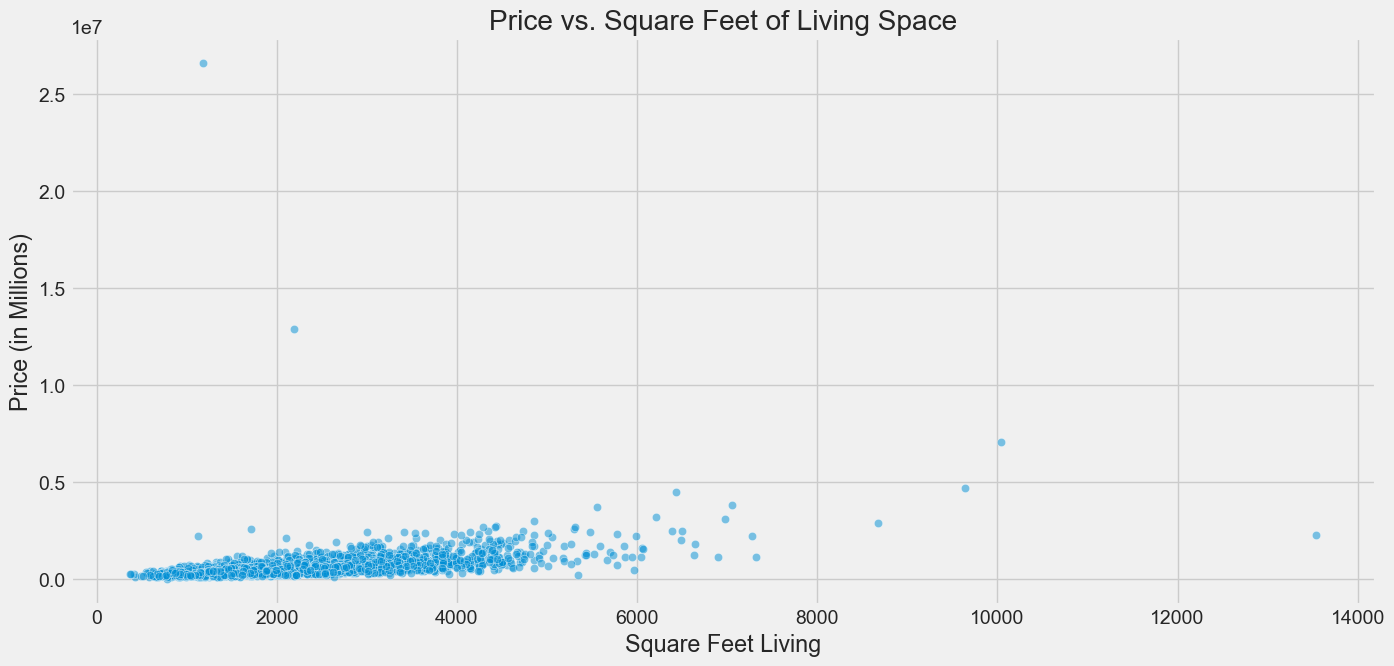

In [22]:
# Scatter plot of living area vs. price
plt.figure(figsize=(15, 7))
sns.scatterplot(x='sqft_living', y='price', data=df, alpha=0.5)
plt.title('Price vs. Square Feet of Living Space')
plt.xlabel('Square Feet Living')
plt.ylabel('Price (in Millions)')
plt.show()

In [23]:
#Bivariate Analysis - Categorical Features vs. Price

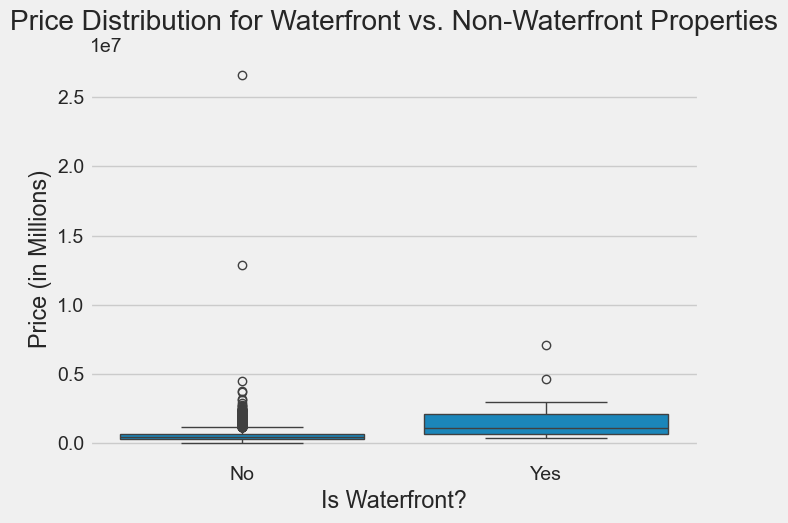

In [24]:
# Box plot to see price distribution by a categorical feature
plt.figure(figsize=(7,5))
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Price Distribution for Waterfront vs. Non-Waterfront Properties')
plt.xticks([0, 1], ['No', 'Yes']) # More readable labels for the x-axis
plt.xlabel('Is Waterfront?')
plt.ylabel('Price (in Millions)')
plt.show()

In [25]:
#Multivariate Analysis - Correlation Heatmap

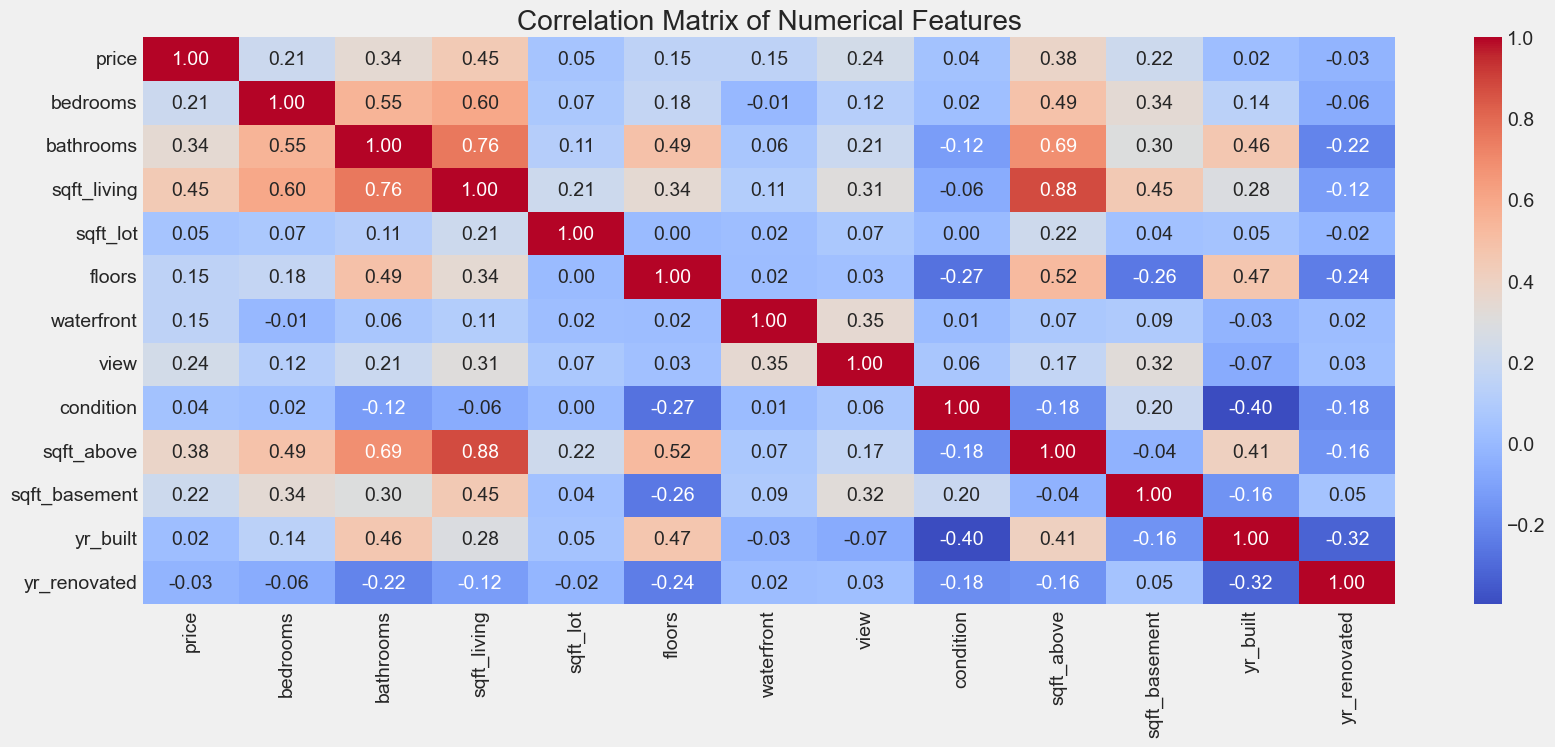

In [26]:
# Create a correlation matrix
plt.figure(figsize=(18, 7))
correlation_matrix = df.corr(numeric_only=True)

# Use seaborn to create a heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [27]:
from sklearn.model_selection import train_test_split

In [28]:
# --- 1. Define Features (X) and Target (y) ---
# Select the features we will use to make predictions.
# We are dropping the original 'date' and the target 'price'.
# We also drop 'street', 'statezip', and 'country' for now.

In [29]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
            'waterfront', 'view', 'condition', 'sqft_above',
            'sqft_basement', 'yr_built', 'yr_renovated', 'city']
X = df[features]

# Select the target variable
y = df['price']

In [30]:
# --- 2. Perform the Train-Test Split ---

# Split the data into training (80%) and testing (20%) sets.
# random_state ensures that we get the same split every time we run the code.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
# --- 3. Verify the results ---

print(f"Shape of the original dataset: {df.shape}")
print("---")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print("---")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of the original dataset: (4551, 18)
---
Shape of X_train: (3640, 13)
Shape of X_test: (911, 13)
---
Shape of y_train: (3640,)
Shape of y_test: (911,)


In [33]:
# One-Hot Encoding Begins!!

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [35]:
# --- 1. Identify the categorical column ---
categorical_feature = ['city']

In [36]:
# --- 2. Set up the OneHotEncoder ---
# handle_unknown='ignore' tells the encoder to ignore categories that appear in the
# test set but not in the training set.
# sparse_output=False ensures the output is a dense numpy array, not a sparse matrix.
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [37]:
# --- 3. Fit and Transform the data ---
# We 'fit' the encoder ONLY on the training data to learn the categories.
# Then we 'transform' both the training and testing data.
encoded_train = encoder.fit_transform(X_train[categorical_feature])
encoded_test = encoder.transform(X_test[categorical_feature])

In [38]:
# The output of the encoder is a numpy array. Let's create a new DataFrame from it.
# The column names are created using the encoder's get_feature_names_out method.
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(categorical_feature), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(categorical_feature), index=X_test.index)

In [39]:
# --- 4. Combine with original data and remove the original 'city' column ---
# Drop the original 'city' column from the training and test sets
X_train_numeric = X_train.drop(columns=categorical_feature)
X_test_numeric = X_test.drop(columns=categorical_feature)

In [40]:
# Concatenate the original numeric data with the new encoded data
X_train_processed = pd.concat([X_train_numeric, encoded_train_df], axis=1)
X_test_processed = pd.concat([X_test_numeric, encoded_test_df], axis=1)

In [41]:
# --- 5. Verify the results ---
print("Original shape of X_train:", X_train.shape)
print("Shape of X_train after One-Hot Encoding:", X_train_processed.shape)
print("\nFirst 5 rows of the new processed training data:")
print(X_train_processed.head())

Original shape of X_train: (3640, 13)
Shape of X_train after One-Hot Encoding: (3640, 54)

First 5 rows of the new processed training data:
      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
4134       4.0       1.75         1360      4840     1.5           0     0   
2098       3.0       2.25         2210      8000     2.0           0     0   
3706       3.0       1.00         1200      8514     1.0           0     0   
4055       3.0       2.50         2860     43821     2.0           0     0   
2153       3.0       1.75         1760     10780     1.0           0     0   

      condition  sqft_above  sqft_basement  ...  city_SeaTac  city_Seattle  \
4134          4        1360              0  ...          0.0           1.0   
2098          4        2210              0  ...          0.0           0.0   
3706          3        1200              0  ...          0.0           0.0   
4055          4        2860              0  ...          0.0           0.0   
2

In [42]:
#Model Building: Training a Linear Regression Model

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
# --- 1. Create an instance of the Linear Regression model ---
linear_model = LinearRegression()

In [45]:
# --- 2. Train (fit) the model on the processed training data ---
# This is where the model 'learns' from the data.
linear_model.fit(X_train_processed, y_train)

# --- 3. Print a confirmation message ---
print("Linear Regression model has been successfully trained!")

Linear Regression model has been successfully trained!


In [46]:
#Model Evaluation: Assessing the Linear Regression Model

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

In [48]:
# --- 1. Make predictions on the test data ---
y_pred = linear_model.predict(X_test_processed)

In [49]:
# --- 2. Calculate Evaluation Metrics ---

In [50]:
# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate R-squared (R2) score
r2 = r2_score(y_test, y_pred)

In [51]:
print("--- Linear Regression Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2 Score): {r2:.4f}")

--- Linear Regression Model Evaluation ---
Root Mean Squared Error (RMSE): $218,879.58
R-squared (R2 Score): 0.6780


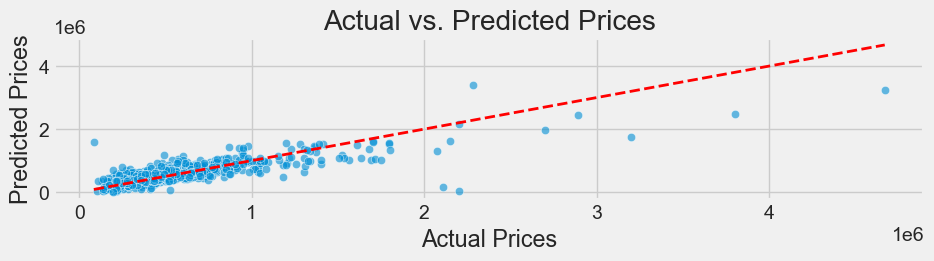

In [52]:
# --- 3. Visualize the Predictions vs. Actual Prices ---

plt.figure(figsize=(10, 2))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Diagonal line
plt.title('Actual vs. Predicted Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.show()

In [53]:
# Random Forest Model

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [55]:
# --- 1. Create an instance of the Random Forest model ---
# n_estimators is the number of trees in the forest.
# random_state ensures reproducibility.
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

In [56]:
# --- 2. Train (fit) the model on the same processed training data ---
print("Training the Random Forest model... (This may take a moment)")
random_forest_model.fit(X_train_processed, y_train)
print("Model training complete!")

Training the Random Forest model... (This may take a moment)
Model training complete!


In [57]:
# --- 3. Make predictions on the test data ---
y_pred_rf = random_forest_model.predict(X_test_processed)

In [58]:
# --- 4. Evaluate the new model ---
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

In [59]:
print("\n--- Random Forest Model Evaluation ---")
print(f"Root Mean Squared Error (RMSE): ${rmse_rf:,.2f}")
print(f"R-squared (R2 Score): {r2_rf:.4f}")

print("\n--- Comparison ---")
print(f"Linear Regression RMSE: $218,879.58")
print(f"Random Forest RMSE:     ${rmse_rf:,.2f}")
print("---")
print(f"Linear Regression R2: 0.6780")
print(f"Random Forest R2:     {r2_rf:.4f}")


--- Random Forest Model Evaluation ---
Root Mean Squared Error (RMSE): $332,957.62
R-squared (R2 Score): 0.2548

--- Comparison ---
Linear Regression RMSE: $218,879.58
Random Forest RMSE:     $332,957.62
---
Linear Regression R2: 0.6780
Random Forest R2:     0.2548


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: CORRECTED Feature Selection (removing 'statezip') ---
# We will use only 'city' for location for now.
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
            'waterfront', 'view', 'condition', 'sqft_above',
            'sqft_basement', 'yr_built', 'yr_renovated', 'city']
X = df[features]
y = df['price']

# --- Step 2: Re-run the Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Re-run the One-Hot Encoding ---
categorical_feature = ['city']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_train = encoder.fit_transform(X_train[categorical_feature])
encoded_test = encoder.transform(X_test[categorical_feature])

encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(categorical_feature), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(categorical_feature), index=X_test.index)

X_train_numeric = X_train.drop(columns=categorical_feature)
X_test_numeric = X_test.drop(columns=categorical_feature)

X_train_processed = pd.concat([X_train_numeric, encoded_train_df], axis=1)
X_test_processed = pd.concat([X_test_numeric, encoded_test_df], axis=1)


# --- Step 4: Re-train and Re-evaluate BOTH models ---

# Linear Regression (to confirm baseline is the same)
print("Training Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
y_pred_lr = linear_model.predict(X_test_processed)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Training complete!")

# Random Forest
print("\nTraining the Random Forest model...")
random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
random_forest_model.fit(X_train_processed, y_train)
y_pred_rf = random_forest_model.predict(X_test_processed)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Training complete!")


# --- Step 5: Final Comparison ---
print("\n--- Final Model Comparison (Corrected) ---")
print(f"Linear Regression RMSE: ${rmse_lr:,.2f} | R2: {r2_lr:.4f}")
print(f"Random Forest RMSE:     ${rmse_rf:,.2f} | R2: {r2_rf:.4f}")

Training Linear Regression model...
Training complete!

Training the Random Forest model...
Training complete!

--- Final Model Comparison (Corrected) ---
Linear Regression RMSE: $218,879.58 | R2: 0.6780
Random Forest RMSE:     $332,957.62 | R2: 0.2548


In [61]:
# --- DEBUGGING STEP ---

# Check for any NaN (missing) values in our final training data
nan_check = X_train_processed.isnull().sum().sum()

print(f"Total number of NaN (missing) values in the processed training data: {nan_check}")

# Check the data types of all columns to be sure they are numeric
print("\nData types of the first 5 and last 5 columns:")
print(X_train_processed.iloc[:, np.r_[0:5, -5:0]].info())

Total number of NaN (missing) values in the processed training data: 0

Data types of the first 5 and last 5 columns:
<class 'pandas.core.frame.DataFrame'>
Index: 3640 entries, 4134 to 860
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   bedrooms              3640 non-null   float64
 1   bathrooms             3640 non-null   float64
 2   sqft_living           3640 non-null   int64  
 3   sqft_lot              3640 non-null   int64  
 4   floors                3640 non-null   float64
 5   city_Snoqualmie Pass  3640 non-null   float64
 6   city_Tukwila          3640 non-null   float64
 7   city_Vashon           3640 non-null   float64
 8   city_Woodinville      3640 non-null   float64
 9   city_Yarrow Point     3640 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 312.8 KB
None


In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Define Feature and Target variables ---
# We select all features and identify which are numerical and which are categorical
target = 'price'
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 
            'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city']

numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
categorical_features = ['city']

X = df[features]
y = df[target]

# --- Step 2: Train-Test Split (same as before) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Step 3: Create a Robust Preprocessing Pipeline using ColumnTransformer ---
# This is the new, improved part

# Create a transformer for numerical features (scaling)
numeric_transformer = StandardScaler()

# Create a transformer for categorical features (one-hot encoding)
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Bundle the transformers into a single ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# --- Step 4: Train and Evaluate the Linear Regression Model ---
# We create a 'pipeline' that first preprocesses the data, then trains the model
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])

print("Training Linear Regression model...")
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)
print("Training complete!")

# --- Step 5: Train and Evaluate the Random Forest Model ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

print("\nTraining the Random Forest model...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Training complete!")


# --- Step 6: Final Comparison ---
print("\n--- Final Model Comparison (Using Robust Pipeline) ---")
print(f"Linear Regression RMSE: ${rmse_lr:,.2f} | R2: {r2_lr:.4f}")
print(f"Random Forest RMSE:     ${rmse_rf:,.2f} | R2: {r2_rf:.4f}")

Training Linear Regression model...
Training complete!

Training the Random Forest model...
Training complete!

--- Final Model Comparison (Using Robust Pipeline) ---
Linear Regression RMSE: $218,878.06 | R2: 0.6780
Random Forest RMSE:     $329,816.10 | R2: 0.2688


In [63]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- Step 1: Create a minimal feature set with ONLY sqft_living ---
X_minimal = df[['sqft_living']]
y_minimal = df['price']

# --- Step 2: Perform a new Train-Test Split ---
X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(X_minimal, y_minimal, test_size=0.2, random_state=42)

# --- Step 3: Create a minimal preprocessing pipeline (just scaling) ---
# We only need to scale the single numerical feature.
preprocessor_min = StandardScaler()

# --- Step 4: Train and Evaluate Linear Regression on ONE feature ---
lr_pipeline_min = Pipeline(steps=[('scaler', preprocessor_min),
                                  ('regressor', LinearRegression())])
lr_pipeline_min.fit(X_train_min, y_train_min)
y_pred_lr_min = lr_pipeline_min.predict(X_test_min)
rmse_lr_min = np.sqrt(mean_squared_error(y_test_min, y_pred_lr_min))
r2_lr_min = r2_score(y_test_min, y_pred_lr_min)

# --- Step 5: Train and Evaluate Random Forest on ONE feature ---
rf_pipeline_min = Pipeline(steps=[('scaler', preprocessor_min),
                                  ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
rf_pipeline_min.fit(X_train_min, y_train_min)
y_pred_rf_min = rf_pipeline_min.predict(X_test_min)
rmse_rf_min = np.sqrt(mean_squared_error(y_test_min, y_pred_rf_min))
r2_rf_min = r2_score(y_test_min, y_pred_rf_min)

# --- Step 6: Compare the results ---
print("--- Minimal Model Comparison (using ONLY sqft_living) ---")
print(f"Linear Regression RMSE: ${rmse_lr_min:,.2f} | R2: {r2_lr_min:.4f}")
print(f"Random Forest RMSE:     ${rmse_rf_min:,.2f} | R2: {r2_rf_min:.4f}")

--- Minimal Model Comparison (using ONLY sqft_living) ---
Linear Regression RMSE: $267,821.97 | R2: 0.5179
Random Forest RMSE:     $306,594.99 | R2: 0.3682


In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Define Features and Target ---
target = 'price'
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 
            'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city']
numerical_features = [col for col in features if col != 'city']
categorical_features = ['city']

X = df[features]
y = df[target]

# --- Step 2: THE FIX - Apply Log Transformation to the Target Variable ---
y_log = np.log1p(y)

# --- Step 3: Train-Test Split on the NEW y_log target ---
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- Step 4: Create the Robust Preprocessing Pipeline (same as before) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ], remainder='passthrough') # Use remainder='passthrough' for safety

# --- Step 5: Train and Evaluate the Random Forest Model ---
# We build the pipeline that preprocesses data and then trains the model
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

print("Training the Random Forest model on log-transformed data...")
rf_pipeline.fit(X_train, y_train_log)

# Predict the LOG prices first
log_predictions = rf_pipeline.predict(X_test)

# IMPORTANT: Convert predictions BACK to the original dollar scale
final_predictions = np.expm1(log_predictions)

# Evaluate using the original y_test (in dollars) and the final_predictions (in dollars)
rmse_rf = np.sqrt(mean_squared_error(y_test, final_predictions))
r2_rf = r2_score(y_test, final_predictions)
print("Training complete!")

# --- Step 6: Final Comparison ---
print("\n--- Final Model Comparison (with Target Transformation) ---")
print(f"Linear Regression (Baseline) RMSE: $218,879.58 | R2: 0.6780")
print(f"Random Forest (Corrected)  RMSE: ${rmse_rf:,.2f} | R2: {r2_rf:.4f}")

Training the Random Forest model on log-transformed data...
Training complete!

--- Final Model Comparison (with Target Transformation) ---
Linear Regression (Baseline) RMSE: $218,879.58 | R2: 0.6780
Random Forest (Corrected)  RMSE: $235,640.28 | R2: 0.6268


In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

# --- Step 1: Define Feature and Target variables ---
target = 'price'

# THE ONLY CHANGE IS HERE: 'sqft_lot' has been removed from the list of features.
numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated']
categorical_features = ['city']
features = numerical_features + categorical_features

X = df[features]
y = df[target]

y_log = np.log1p(y)

# --- Step 2: Train-Test Split ---
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# --- Step 3: Create the Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- Step 4: Train and Evaluate Linear Regression ---
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train_log)
lr_log_predictions = lr_pipeline.predict(X_test)
lr_final_predictions = np.expm1(lr_log_predictions)
rmse_lr = np.sqrt(mean_squared_error(y_test, lr_final_predictions))
r2_lr = r2_score(y_test, lr_final_predictions)

# --- Step 5: Train and Evaluate Random Forest ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])
rf_pipeline.fit(X_train, y_train_log)
rf_log_predictions = rf_pipeline.predict(X_test)
rf_final_predictions = np.expm1(rf_log_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_final_predictions))
r2_rf = r2_score(y_test, rf_final_predictions)

# --- Step 6: Final, Final Comparison ---
print("\n--- Final Comparison (After Removing 'sqft_lot') ---")
print(f"Linear Regression RMSE: ${rmse_lr:,.2f} | R2: {r2_lr:.4f}")
print(f"Random Forest RMSE:     ${rmse_rf:,.2f} | R2: {r2_rf:.4f}")


--- Final Comparison (After Removing 'sqft_lot') ---
Linear Regression RMSE: $1,019,307.61 | R2: -5.9838
Random Forest RMSE:     $235,773.61 | R2: 0.6263


In [66]:
# --- Feature Engineering ---

In [67]:
# 1. Create the 'house_age' feature
# Since all sales occurred in 2014, we can calculate the age relative to that year.
df['house_age'] = 2014 - df['yr_built']

# 2. Create the 'is_renovated' feature
# We use np.where to create a binary flag: 1 if yr_renovated is not 0, else 0.
df['is_renovated'] = np.where(df['yr_renovated'] == 0, 0, 1)

In [68]:
# --- Verify the new features ---
# We'll display the original year columns alongside our new features to see the result.
print("DataFrame with new 'house_age' and 'is_renovated' features:")
print(df[['yr_built', 'house_age', 'yr_renovated', 'is_renovated']].head())

# Also, let's see how many houses have been renovated
print("\nCounts of renovated vs. non-renovated houses:")
print(df['is_renovated'].value_counts())

DataFrame with new 'house_age' and 'is_renovated' features:
   yr_built  house_age  yr_renovated  is_renovated
0      1955         59          2005             1
1      1921         93             0             0
2      1966         48             0             0
3      1963         51             0             0
4      1976         38          1992             1

Counts of renovated vs. non-renovated houses:
is_renovated
0    2706
1    1845
Name: count, dtype: int64


In [69]:
#Training the XGBoost Model
!pip install xgboost

In [70]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [71]:
# --- Step 1: Define Feature and Target variables with our new features ---
target = 'price'

# We include our new features and exclude the problematic 'sqft_lot' and original year columns
numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 
                      'house_age', 'is_renovated'] # Added new features
categorical_features = ['city']
features = numerical_features + categorical_features

In [72]:
X = df[features]
y = df[target]

y_log = np.log1p(y)

In [73]:
# --- Step 2: Train-Test Split ---
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [74]:
# --- Step 3: Create the Preprocessing Pipeline ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

In [75]:
# --- Step 4: Train and Evaluate the XGBoost Model ---
# We create a pipeline that preprocesses the data, then trains the XGBoost regressor
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror', 
                                                              n_estimators=100, 
                                                              random_state=42,
                                                              n_jobs=-1))])

print("Training the XGBoost model...")
xgb_pipeline.fit(X_train, y_train_log)

Training the XGBoost model...


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'floors',
                                                   'waterfront', 'view',
                                                   'condition', 'sqft_above',
                                                   'sqft_basement', 'house_age',
                                                   'is_renovated']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city'])])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=N...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [76]:
# Predict the LOG prices first
log_predictions_xgb = xgb_pipeline.predict(X_test)

# Convert predictions BACK to the original dollar scale
final_predictions_xgb = np.expm1(log_predictions_xgb)

# Evaluate using the original y_test (in dollars) and the final_predictions (in dollars)
rmse_xgb = np.sqrt(mean_squared_error(y_test, final_predictions_xgb))
r2_xgb = r2_score(y_test, final_predictions_xgb)
print("Training complete!")

Training complete!


In [77]:
# --- Step 5: Final Comparison of All Models ---
print("\n--- Final Project Model Comparison ---")
print(f"Linear Regression (Baseline)      RMSE: $218,879.58 | R2: 0.6780")
print(f"Random Forest (Corrected)         RMSE: $235,773.61 | R2: 0.6263")
print(f"XGBoost (Feature Engineered)      RMSE: ${rmse_xgb:,.2f} | R2: {r2_xgb:.4f}")



--- Final Project Model Comparison ---
Linear Regression (Baseline)      RMSE: $218,879.58 | R2: 0.6780
Random Forest (Corrected)         RMSE: $235,773.61 | R2: 0.6263
XGBoost (Feature Engineered)      RMSE: $239,267.44 | R2: 0.6152


In [78]:
# The Premium for a Waterfront View

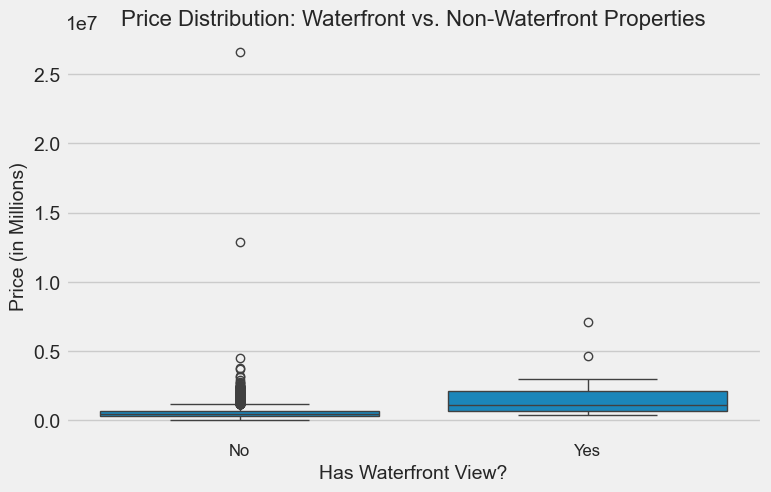

In [79]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='waterfront', y='price', data=df)
plt.title('Price Distribution: Waterfront vs. Non-Waterfront Properties', fontsize=16)
plt.xticks([0, 1], ['No', 'Yes'], fontsize=12)
plt.xlabel('Has Waterfront View?', fontsize=14)
plt.ylabel('Price (in Millions)', fontsize=14)
plt.show()

In [80]:
# The Value of a Well-Maintained Home

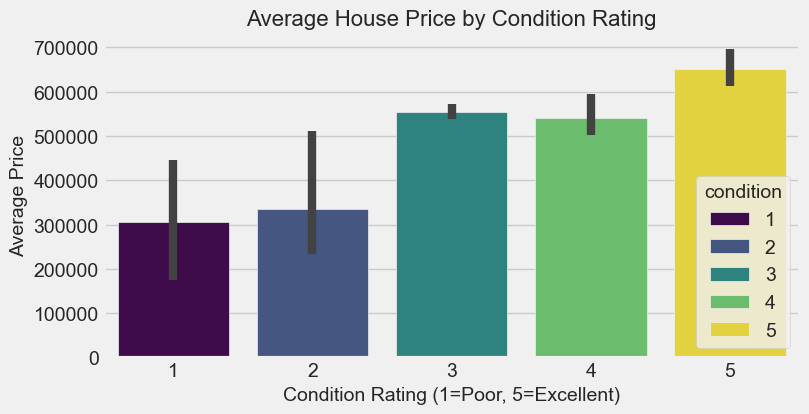

In [81]:
plt.figure(figsize=(8, 4))
sns.barplot(x='condition', y='price', data=df, hue='condition', palette='viridis')
plt.title('Average House Price by Condition Rating', fontsize=16)
plt.xlabel('Condition Rating (1=Poor, 5=Excellent)', fontsize=14)
plt.ylabel('Average Price', fontsize=14)
plt.show()

In [82]:
# Group the data by 'condition' and calculate key metrics
condition_analysis = df.groupby('condition').agg(
    average_price=('price', 'mean'),
    average_sqft_living=('sqft_living', 'mean'),
    number_of_houses=('price', 'count')
).reset_index()

# Sort by condition for clarity
condition_analysis = condition_analysis.sort_values('condition')

print(condition_analysis)

   condition  average_price  average_sqft_living  number_of_houses
0          1  306633.333333          1325.000000                 6
1          2  334837.419355          1517.741935                31
2          3  554742.409552          2210.455630              2851
3          4  539682.069598          1982.882068              1238
4          5  652030.529840          2100.256471               425


In [83]:
# Building the Deep Learning Model - Multi-Layer Perceptron (MLP)

In [84]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [85]:
# --- Create and Train the Deep Learning Model (MLP) ---
# We define the 'hidden_layer_sizes'. (100, 50) means two hidden layers:
# the first with 100 neurons and the second with 50.
# max_iter=500 gives the network enough time to converge.
mlp_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50),
                                                          activation='relu',
                                                          solver='adam',
                                                          max_iter=500,
                                                          random_state=42))])

print("Training the Deep Learning (MLP) model... (This may take a few moments)")
mlp_pipeline.fit(X_train, y_train_log)

Training the Deep Learning (MLP) model... (This may take a few moments)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bedrooms', 'bathrooms',
                                                   'sqft_living', 'floors',
                                                   'waterfront', 'view',
                                                   'condition', 'sqft_above',
                                                   'sqft_basement', 'house_age',
                                                   'is_renovated']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['city'])])),
                ('regressor',
                 MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500,
                              random_state=42))])

In [86]:
# --- Predict and Evaluate ---
# Predict the LOG prices first
log_predictions_mlp = mlp_pipeline.predict(X_test)

In [87]:
# Convert predictions BACK to the original dollar scale
final_predictions_mlp = np.expm1(log_predictions_mlp)

# Calculate the final metrics
rmse_mlp = np.sqrt(mean_squared_error(y_test, final_predictions_mlp))
r2_mlp = r2_score(y_test, final_predictions_mlp)
print("Training complete!")

Training complete!


In [88]:
print(f"Deep Learning (MLP)    RMSE: ${rmse_mlp:,.2f} | R2: {r2_mlp:.4f}")

Deep Learning (MLP)    RMSE: $16,480,917.29 | R2: -1824.7708


In [89]:
# Linear Regression Model

In [90]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Reload and Clean Data ---
df = pd.read_csv('House_Price_Prediction.csv')
df = df[df['price'] != 0] # Remove zero-priced homes

# --- Feature Selection for the Original Model ---
# This is the key part: we are using the original feature set.
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 
            'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 
            'yr_renovated', 'city']
X = df[features]
y = df['price']

# --- Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Manual One-Hot Encoding (as we did originally) ---
# Separate categorical feature
categorical_feature = ['city']

# Setup encoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit on training and transform both sets
encoded_train = encoder.fit_transform(X_train[categorical_feature])
encoded_test = encoder.transform(X_test[categorical_feature])

# Create DataFrames from the encoded arrays
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder.get_feature_names_out(categorical_feature), index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder.get_feature_names_out(categorical_feature), index=X_test.index)

# Drop original 'city' and concatenate
X_train_processed = pd.concat([X_train.drop(columns=categorical_feature), encoded_train_df], axis=1)
X_test_processed = pd.concat([X_test.drop(columns=categorical_feature), encoded_test_df], axis=1)

# --- Train and Evaluate the Linear Regression Model ---
print("Training the original Linear Regression model...")
linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)

y_pred = linear_model.predict(X_test_processed)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n--- Original Linear Regression Results ---")
print(f"RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Training the original Linear Regression model...

--- Original Linear Regression Results ---
RMSE: $218,879.58 | R2: 0.6780


In [91]:
# Random Forest Model Separaetly

In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Prep for Advanced Models ---
# Create engineered features
if 'house_age' not in df.columns:
    df['house_age'] = 2014 - df['yr_built']
if 'is_renovated' not in df.columns:
    df['is_renovated'] = np.where(df['yr_renovated'] == 0, 0, 1)

# Feature selection (WITHOUT sqft_lot)
target = 'price'
numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 
                      'house_age', 'is_renovated']
categorical_features = ['city']
features = numerical_features + categorical_features

X = df[features]
y = df[target]
y_log = np.log1p(y)

# Train-Test Split
X_train, X_test, y_train_log, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
original_y_test = y.loc[y_test.index] # Get original prices for final evaluation

# Preprocessing Pipeline (using robust ColumnTransformer, no scaling for RF)
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)], 
    remainder='passthrough')

# --- Train and Evaluate the Random Forest Model ---
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor), 
                              ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))])

print("Training the corrected Random Forest model...")
rf_pipeline.fit(X_train, y_train_log)
log_predictions = rf_pipeline.predict(X_test)
final_predictions = np.expm1(log_predictions)

rmse = np.sqrt(mean_squared_error(original_y_test, final_predictions))
r2 = r2_score(original_y_test, final_predictions)

print("\n--- Corrected Random Forest Results ---")
print(f"RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Training the corrected Random Forest model...

--- Corrected Random Forest Results ---
RMSE: $235,253.58 | R2: 0.6280


In [93]:
#Deep Learning Model Separately

In [94]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Prep for Advanced Models (same as RF) ---
if 'house_age' not in df.columns:
    df['house_age'] = 2014 - df['yr_built']
if 'is_renovated' not in df.columns:
    df['is_renovated'] = np.where(df['yr_renovated'] == 0, 0, 1)

target = 'price'
numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 
                      'house_age', 'is_renovated']
categorical_features = ['city']
features = numerical_features + categorical_features

X = df[features]
y = df[target]
y_log = np.log1p(y)

# Train-Test Split
X_train, X_test, y_train_log, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
original_y_test = y.loc[y_test.index]

# Preprocessing Pipeline (WITH SCALING for MLP)
preprocessor_dl = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- Train and Evaluate the Deep Learning Model ---
mlp_pipeline = Pipeline(steps=[('preprocessor', preprocessor_dl), 
                               ('regressor', MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42))])

print("Training the corrected Deep Learning model...")
mlp_pipeline.fit(X_train, y_train_log)
log_predictions = mlp_pipeline.predict(X_test)
final_predictions = np.expm1(log_predictions)

rmse = np.sqrt(mean_squared_error(original_y_test, final_predictions))
r2 = r2_score(original_y_test, final_predictions)

print("\n--- Corrected Deep Learning (MLP) Results ---")
print(f"RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Training the corrected Deep Learning model...

--- Corrected Deep Learning (MLP) Results ---
RMSE: $16,480,917.29 | R2: -1824.7708


In [95]:
# XGBoost Model Separately

In [96]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# --- Step 1: Load and Clean Data ---
df = pd.read_csv('House_Price_Prediction.csv')
df = df[df['price'] != 0] # Remove zero-priced homes

# --- Step 2: Feature Engineering ---
if 'house_age' not in df.columns:
    df['house_age'] = 2014 - df['yr_built']
if 'is_renovated' not in df.columns:
    df['is_renovated'] = np.where(df['yr_renovated'] == 0, 0, 1)

# --- Step 3: Feature Selection for Advanced Models ---
target = 'price'
# This is our final, stable feature set (WITHOUT sqft_lot)
numerical_features = ['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 
                      'view', 'condition', 'sqft_above', 'sqft_basement', 
                      'house_age', 'is_renovated']
categorical_features = ['city']
features = numerical_features + categorical_features

X = df[features]
y = df[target]
y_log = np.log1p(y)

# --- Step 4: Train-Test Split ---
X_train, X_test, y_train_log, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
original_y_test = y.loc[y_test.index] # Get original prices for final evaluation

# --- Step 5: Preprocessing Pipeline (with scaling, as XGBoost can benefit from it) ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# --- Step 6: Train and Evaluate the XGBoost Model ---
xgb_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', xgb.XGBRegressor(objective='reg:squarederror',
                                                              n_estimators=100,
                                                              random_state=42,
                                                              n_jobs=-1))])

print("Training the corrected XGBoost model...")
xgb_pipeline.fit(X_train, y_train_log)

# Predict the LOG prices first
log_predictions = xgb_pipeline.predict(X_test)

# Convert predictions BACK to the original dollar scale
final_predictions = np.expm1(log_predictions)

# Calculate the final metrics
rmse = np.sqrt(mean_squared_error(original_y_test, final_predictions))
r2 = r2_score(original_y_test, final_predictions)

print("\n--- Corrected XGBoost Results ---")
print(f"RMSE: ${rmse:,.2f} | R2: {r2:.4f}")

Training the corrected XGBoost model...

--- Corrected XGBoost Results ---
RMSE: $239,267.44 | R2: 0.6152


In [97]:
!pip install graphviz

In [99]:
import graphviz

# Create a new directed graph
dot = graphviz.Digraph('ProjectWorkflow', comment='Our Project Workflow')
dot.attr(rankdir='LR', size='10,5') # LR = Left to Right layout

# Define node styles
dot.attr('node', shape='box', style='rounded,filled', fillcolor='lightblue', fontname='Helvetica')
# Define edge styles
dot.attr('edge', fontname='Helvetica', fontsize='10')

# Create the nodes (steps in the workflow)
dot.node('A', 'Step 1:\nData Cleaning\n& Preparation')
dot.node('B', 'Step 2:\nExploratory\nData Analysis (EDA)')
dot.node('C', 'Step 3:\nFeature\nEngineering')
dot.node('D', 'Step 4:\nComparative\nModel Building')
dot.node('E', 'Step 5:\nFinal Evaluation\n& Conclusion')

# Create the edges (arrows connecting the steps)
dot.edge('A', 'B', label='Clean Data')
dot.edge('B', 'C', label='Find Insights')
dot.edge('C', 'D', label='Enhance Data')
dot.edge('D', 'E', label='Compare Models')

# Save the diagram to a file
try:
    dot.render('project_workflow', format='png', view=False, cleanup=True)
    print("Success! A file named 'project_workflow.png' has been created.")
except graphviz.backend.execute.ExecutableNotFound:
    print("Error: Graphviz executable not found.")
    print("Please install Graphviz on your system (e.g., 'brew install graphviz' on Mac, 'sudo apt-get install graphviz' on Ubuntu).")

Error: Graphviz executable not found.
Please install Graphviz on your system (e.g., 'brew install graphviz' on Mac, 'sudo apt-get install graphviz' on Ubuntu).
